# 1. Import the Required Libraries 

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from mplsoccer import Pitch, Sbopen, VerticalPitch
from matplotlib.patches import Patch

# 2. Load the Dataset

The first thing to do is open the data. We use a parser SBopen available in mplsoccer. Using method 'event' and puting the id of the game as a parameter we load the data. 

The event data is stored in a dataframe 'df.' From this dataframe we take out the names of the two teams, then we filter the dataframe so that only shots are left:

In [2]:
parser = Sbopen()
df, relalated, freeze, tactics = parser.event(3923881)
#get the team names 
team1, team2 = df.team_name.unique()
# A dataframe for shots 
shots = df.loc[df['type_name'] == 'Shot'].set_index('id')

## 2.1 Making the Shot Map using Iterative Solution

The first step is to assign each team with it's respective color. Then draw a pitch by setting variables for the pitch length anf width to the Statsbomb coordinate system. 

Now to make the shot map, iterate through all shots in the match. Take the x and y coordinates, the team name and information if a goal was scored. If it was scored, plot a solid circle with the player's name, if not, plot a translucent circle using alpha. 

To have Nigeria's shots and Ivory Coast' shots, substract the x and y from the pitch length and height. 

Football data tends to be attacking left to right, use this as a default:


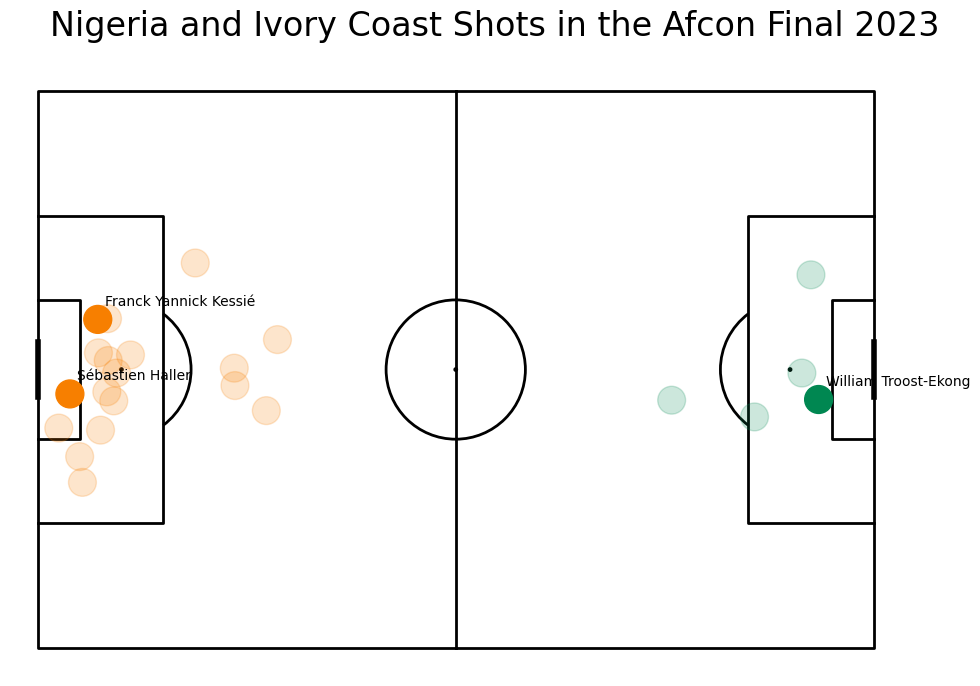

In [3]:
NIG_COLOR = "#008751"   # green
COTE_COLOR = "#F77F00" # orange

pitch = Pitch(line_color = "black")
fig, ax = pitch.draw(figsize=(10, 7))
#Size of the pitch in yards (!!!)
pitchLengthX = 120
pitchWidthY = 80

#Plot the shots by looping through them.
for i,shot in shots.iterrows():
    #get the information
    x=shot['x']
    y=shot['y']
    goal=shot['outcome_name']=='Goal'
    team_name=shot['team_name']
    #set circlesize
    circleSize=2
    #plot Nigeria
    if (team_name==team1):
        if goal:
            shotCircle=plt.Circle((x,y),circleSize,color=NIG_COLOR)
            plt.text(x+1,y-2,shot['player_name'])
        else:
            shotCircle=plt.Circle((x,y),circleSize,color=NIG_COLOR)
            shotCircle.set_alpha(.2)
    #plot Ivorycoast
    else:
        if goal:
            shotCircle=plt.Circle((pitchLengthX-x,pitchWidthY - y),circleSize,color=COTE_COLOR)
            plt.text(pitchLengthX-x+1,pitchWidthY - y - 2 ,shot['player_name'])
        else:
            shotCircle=plt.Circle((pitchLengthX-x,pitchWidthY - y),circleSize,color=COTE_COLOR)
            shotCircle.set_alpha(.2)
    ax.add_patch(shotCircle)
#set title
fig.suptitle("Nigeria and Ivory Coast Shots in the Afcon Final 2023", fontsize = 24)
plt.show()

# 2.2 Plotting Shot Map Using mplsoccer's Pitch Class

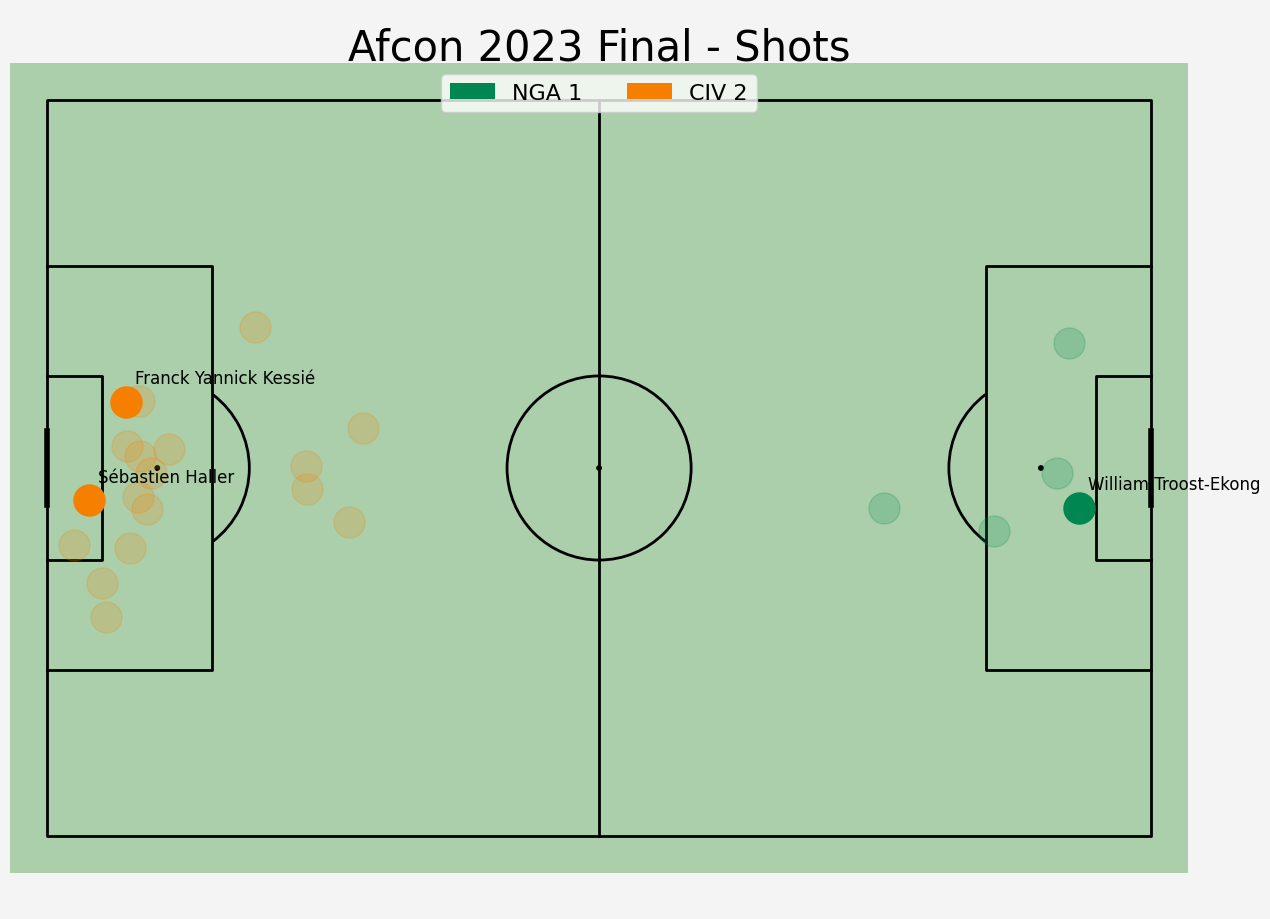

In [9]:

# create pitch (translucent green background)
pitch = Pitch(
    pitch_color=(34/255, 139/255, 34/255, 0.35),  # translucent green
    line_color='black'
)

fig, ax = pitch.grid(
    grid_height=0.9,
    title_height=0.06,
    axis=False,
    endnote_height=0.04,
    title_space=0,
    endnote_space=0
)

# optional: slightly darker figure background for contrast
fig.set_facecolor('#f4f4f4')


# query
mask_nigeria = (df.type_name == 'Shot') & (df.team_name == team1)

# finding rows in the df and keeping only necessary columns
df_nigeria = df.loc[mask_nigeria, ['x', 'y', 'outcome_name', "player_name"]]

# plot them - if shot ended with Goal - alpha 1 and add name
# for Nigeria
for i, row in df_nigeria.iterrows():
    if row["outcome_name"] == 'Goal':
        pitch.scatter(row.x, row.y, alpha=1, s=500, color=NIG_COLOR, ax=ax['pitch'])
        pitch.annotate(row["player_name"], (row.x + 1, row.y - 2),
                       ax=ax['pitch'], fontsize=12)
    else:
        pitch.scatter(row.x, row.y, alpha=0.2, s=500,
                      color=NIG_COLOR, ax=ax['pitch'])

mask_ivory_coast = (df.type_name == 'Shot') & (df.team_name == team2)
df_ivory_coast = df.loc[mask_ivory_coast, ['x', 'y', 'outcome_name', "player_name"]]

# for Ivory Coast we need to revert coordinates
for i, row in df_ivory_coast.iterrows():
    if row["outcome_name"] == 'Goal':
        pitch.scatter(120 - row.x, 80 - row.y, alpha=1, s=500,
                      color=COTE_COLOR, ax=ax['pitch'])
        pitch.annotate(row["player_name"],
                       (120 - row.x + 1, 80 - row.y - 2),
                       ax=ax['pitch'], fontsize=12)
    else:
        pitch.scatter(120 - row.x, 80 - row.y, alpha=0.2,
                      s=500, color=COTE_COLOR, ax=ax['pitch'])

# Simple title
fig.suptitle("Afcon 2023 Final - Shots", fontsize=30)

# Create custom legend with colored country names
legend = ax['pitch'].legend(
    handles=[],
    labels=['NGA   1  -  2   CIV'],
    loc='upper center',
    fontsize=20,
    frameon=True
)

legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.95)

ax['pitch'].legend(handles=legend_elements,
                   loc='upper center',
                   fontsize=16,
                   frameon=True,
                   ncol=2)

plt.show()

# 2.3 Plotting Shots on One Half 

To plot shots on only one team on one half use verticalPitch() class. If half is set to True, only one half of the pitch will be plotted. This is a nice way of plotting shots since they rarely occur on the defensive half. 

Plot all shots at once without looping through the dataframe:

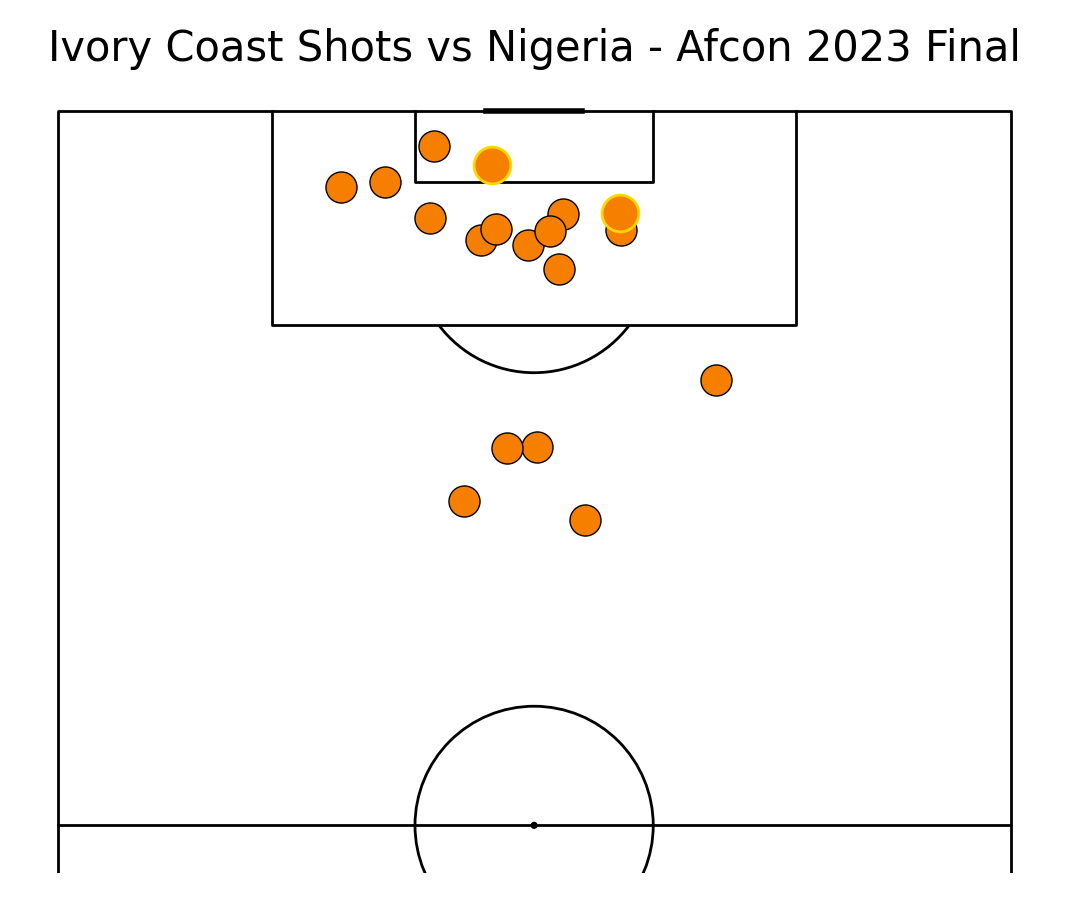

In [5]:

pitch = VerticalPitch(line_color='black', half = True)
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
#plotting all shots
pitch.scatter(df_ivory_coast.x, df_ivory_coast.y,
              alpha = 1,
              s = 500, 
              color = COTE_COLOR,
              ax=ax['pitch'], 
              edgecolors="black")

# Highlight goals
goals = df_ivory_coast[df_ivory_coast['outcome_name'] == 'Goal']
pitch.scatter(goals.x, goals.y,
              s=700,              # slightly bigger
              color= COTE_COLOR,
              edgecolors='gold',  # makes goals pop
              linewidth=2,
              ax=ax['pitch'],
              zorder=5)

fig.suptitle("Ivory Coast Shots vs Nigeria - Afcon 2023 Final", fontsize=30)
plt.show()